In [ ]:
import os
import copy
import json
import time
from pathlib import Path
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from dateutil.relativedelta import relativedelta
import sys
sys.path.append("../src")
from dateutil.relativedelta import relativedelta

from Models.model import GLSTMBatch
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"
RUN_MODE = "quick"  # quick or full
if RUN_MODE == "full":
    start_date = "2000-01-01"
    end_date   = "2025-12-31"

elif RUN_MODE == "custom":
    start_date = "2010-01-01"
    end_date   = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"

eps          = 1e-6
window_size  = 40
horizon      = 2
criterion_km = 120
lstm_layers  = 1
dropout      = 0.3
K            = 6
batch_size   = 64
num_workers  = 0
vertex_idx   = 32
weight_decay = 5e-4
test_lstm    = False
learn_adj    = True
loss_fn = weighted_mse_loss
topology     = 'knn'  # 'knn' ou 'distance'

catalog_dir = Path("..") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)
    



# Carregamento dos arquivos NetCDF (Datasets)


dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc").sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

c:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Done loading datasets in memory
Time taken: 0.93 seconds
Dataset com 731 dias disponíveis.


# Extração do dataset do ERA-5





Input features
 - Daily precipitation (1980-2025)
 - vertical velocity of wind (2006-2025)
 - Temperature and dewpoint (2005-2025)
 - u-v components of wind (2014-2025)

The tensor $X$ has shape $[days, nodes, features]$, with all dataset available, with the $X$ we construct the time windows $X_s$ (inputs) and $y_s$ (targets)



In [18]:
vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_dataset = daily_temp_features(rea_temp)

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1


X_tp = tensor_data_precip(rea_tp, t1=start_date, t2=end_date, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_dataset, estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")

#X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

#X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
#                           estacoes_RS,
#                           start=start_date,
#                           end=end_date,
#                           u_var="u",
#                           v_var="v"
#                           ).reshape(X_tp.shape[0], X
# _tp.shape[1], -1)

In [17]:
print(X_tp.shape)
print(X_year.shape)
print(X_temp.shape)
print(X_vv.shape)

torch.Size([731, 62, 1])
torch.Size([731, 62, 1])
torch.Size([731, 62, 6])
torch.Size([731, 62, 12])


# Creating temporal dataset

The tensor X is transformed in two new tensors, $X_s$ and $y_s$ (inputs and targets), such that: 

 - $X_s$: $[B, W_{in}, N, F]$;
 - $y_s$: $[B, W_{out}, N]$;
 - $B$ : number of time windows created, with $W_{in}$ days of feed to forecast the next $W_{out}$ days;
 - $N$  : number of nodes (stations)
 - $F$  : number of input features by node



In [260]:
#CRIAÇÃO DE JANELAS DE TEMPO

Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)

X_train, y_train, X_val, y_val, X_test, y_test_raw = train_split(Xs, ys)


target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test_raw, target_mean, target_std)

"""
X_train[...,0] = torch.log1p(X_train[...,0])
X_val[...,0] = torch.log1p(X_val[...,0])
X_test[...,0] = torch.log1p(X_test[...,0])

y_train = torch.log1p(y_train)
y_val = torch.log1p(y_val)
y_test = torch.log1p(y_test_raw)
"""

# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)


"""
normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)
"""
# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

train batches: 52 val batches: 15 test batches: 8


# Training


In [248]:
def weighted_mse_loss(
    y_pred,
    y_true,
    extreme_quantile=0.9,
    extreme_weight=20,
    is_log=True,
    eps=1e-6
):
    """
    Weighted MSE loss that emphasizes extreme rainfall, compatible with both
    log-transformed and raw targets.

    Args:
        y_pred: torch.Tensor, model predictions
        y_true: torch.Tensor, true values
        extreme_quantile: float, quantile to define "extreme rainfall" (default 0.9)
        extreme_weight: float, weight multiplier for extreme rainfall (default 5.0)
        is_log: bool, whether y_true (and y_pred) are log-transformed (default True)
        eps: small number to prevent log(0)
    """
    # Compute threshold in original scale
    if is_log:
        y_true_orig = torch.expm1(y_true)
        y_pred_orig = torch.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    threshold = torch.quantile(y_true_orig, extreme_quantile)

    # Create weights: extreme rainfall gets high weight
    weights = torch.ones_like(y_true)
    weights[y_true_orig > threshold] = extreme_weight

    # Weighted MSE (compute on original scale if is_log)
    if is_log:
        # compute loss in log space (optional: can use pred vs true in log)
        loss = torch.mean(weights * (y_pred - y_true) ** 2)
    else:
        loss = torch.mean(weights * (y_pred - y_true) ** 2)

    return loss

In [261]:
for lr in [1e-3]:
    for hidden_dim in [64]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout).to(device)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "dataset_size_comp", f"WINDOW_{window_size}_HORIZON_{horizon}_full_dataset")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=300, lr=lr, weight_decay=5e-6, patience=30, criterion=weighted_mse_loss,run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )

========================HIDDEN_DIM: 64=============================
<function weighted_mse_loss at 0x0000014941DA5580>
train_batched_only: use_amp=False
epoch=1/300train_loss=7.236560e+00/val_loss=4.891459e+00/train_mae=1.087875e+00/val_mae=1.344430e+00/val_mape=3.792780e+02/val_r2=-1.677102e+00
epoch=2/300train_loss=5.086917e+00/val_loss=4.360615e+00/train_mae=1.383323e+00/val_mae=1.477164e+00/val_mape=4.376791e+02/val_r2=-2.146989e+00
epoch=3/300train_loss=4.592942e+00/val_loss=4.128804e+00/train_mae=1.449457e+00/val_mae=1.528583e+00/val_mape=4.655311e+02/val_r2=-2.318342e+00
epoch=4/300train_loss=4.414144e+00/val_loss=4.058433e+00/train_mae=1.456309e+00/val_mae=1.553661e+00/val_mape=4.794188e+02/val_r2=-2.420345e+00
epoch=5/300train_loss=4.295609e+00/val_loss=4.046759e+00/train_mae=1.476395e+00/val_mae=1.535402e+00/val_mape=4.718298e+02/val_r2=-2.335356e+00
epoch=6/300train_loss=4.283206e+00/val_loss=4.067491e+00/train_mae=1.472207e+00/val_mae=1.507772e+00/val_mape=4.598441e+02/val_

# Post Train analysis


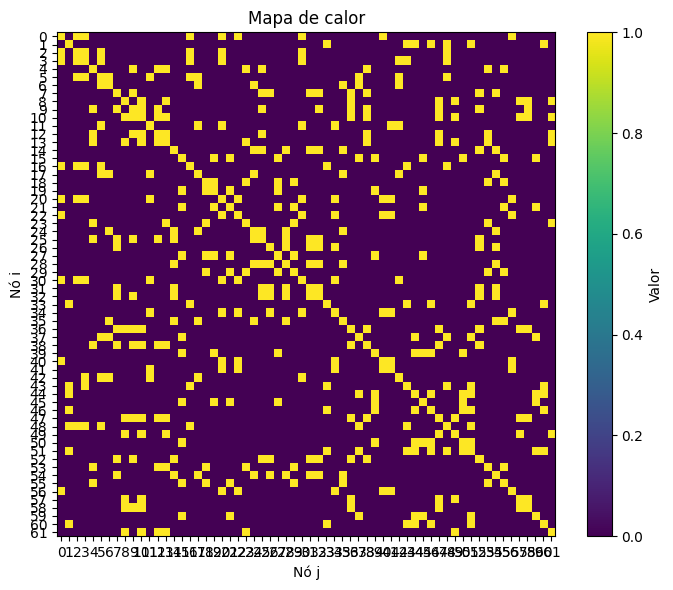

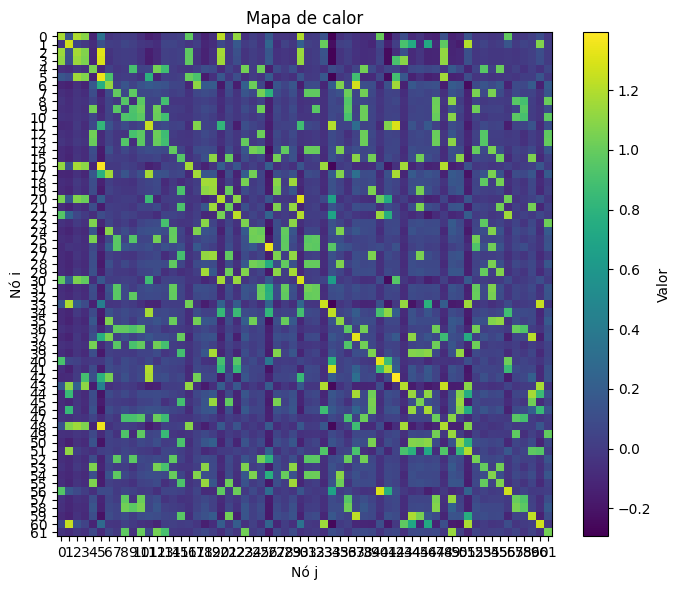

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [251]:
plot_heatmap_nn(torch.abs(adjacency_matrix(N, edge_index)))
plot_heatmap_nn(model.cell_0.A)
# plot_graph(N,graph_matrix_index(model.cell_0.A, threshold=1), pos_knn)

In [ ]:
model.eval()
with torch.no_grad():
    pred  = model(X_test.to(device)).detach().cpu()
    pred_denormalized      = torch.expm1(pred)
    y_test_denormalized    = torch.expm1(y_test)
    
    
def predict(model, X_input, device=device):
    model.eval()
    with torch.no_grad():
        pred = model(X_input.to(device)).detach().cpu()
        return pred



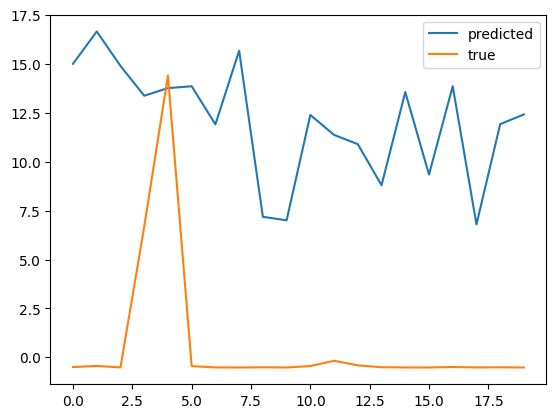

In [258]:
from Evaluation.comparison_plots import _flatten_unique_days
T_max = 20

vertex_idx = 20

#plt.plot(_flatten_unique_days(pred_denormalized, stride=1)[:, vertex_idx])
#plt.plot(_flatten_unique_days(y_test_denormalized, stride=1)[:, vertex_idx])
#plt.legend(['predicted', 'true'])


for vertex_idx in [vertex_idx]:
    plt.plot(5 * _flatten_unique_days(pred_denormalized, stride=1)[:T_max, vertex_idx], label='predicted')
    plt.plot(_flatten_unique_days(y_test_denormalized, stride=1)[:T_max, vertex_idx], label='true')
    plt.legend()
#plt.plot(y_train_denormalized[0:7,:,vertex_idx].reshape(-1,1), label='true')
#plt.plot(pred_denormalized[0:7,:,vertex_idx].reshape(-1,1), label='predict')
#plt.legend()

torch.Size([144, 3, 62]) torch.Size([144, 3, 62])
torch.Size([144, 3, 62]) torch.Size([144, 3, 62])


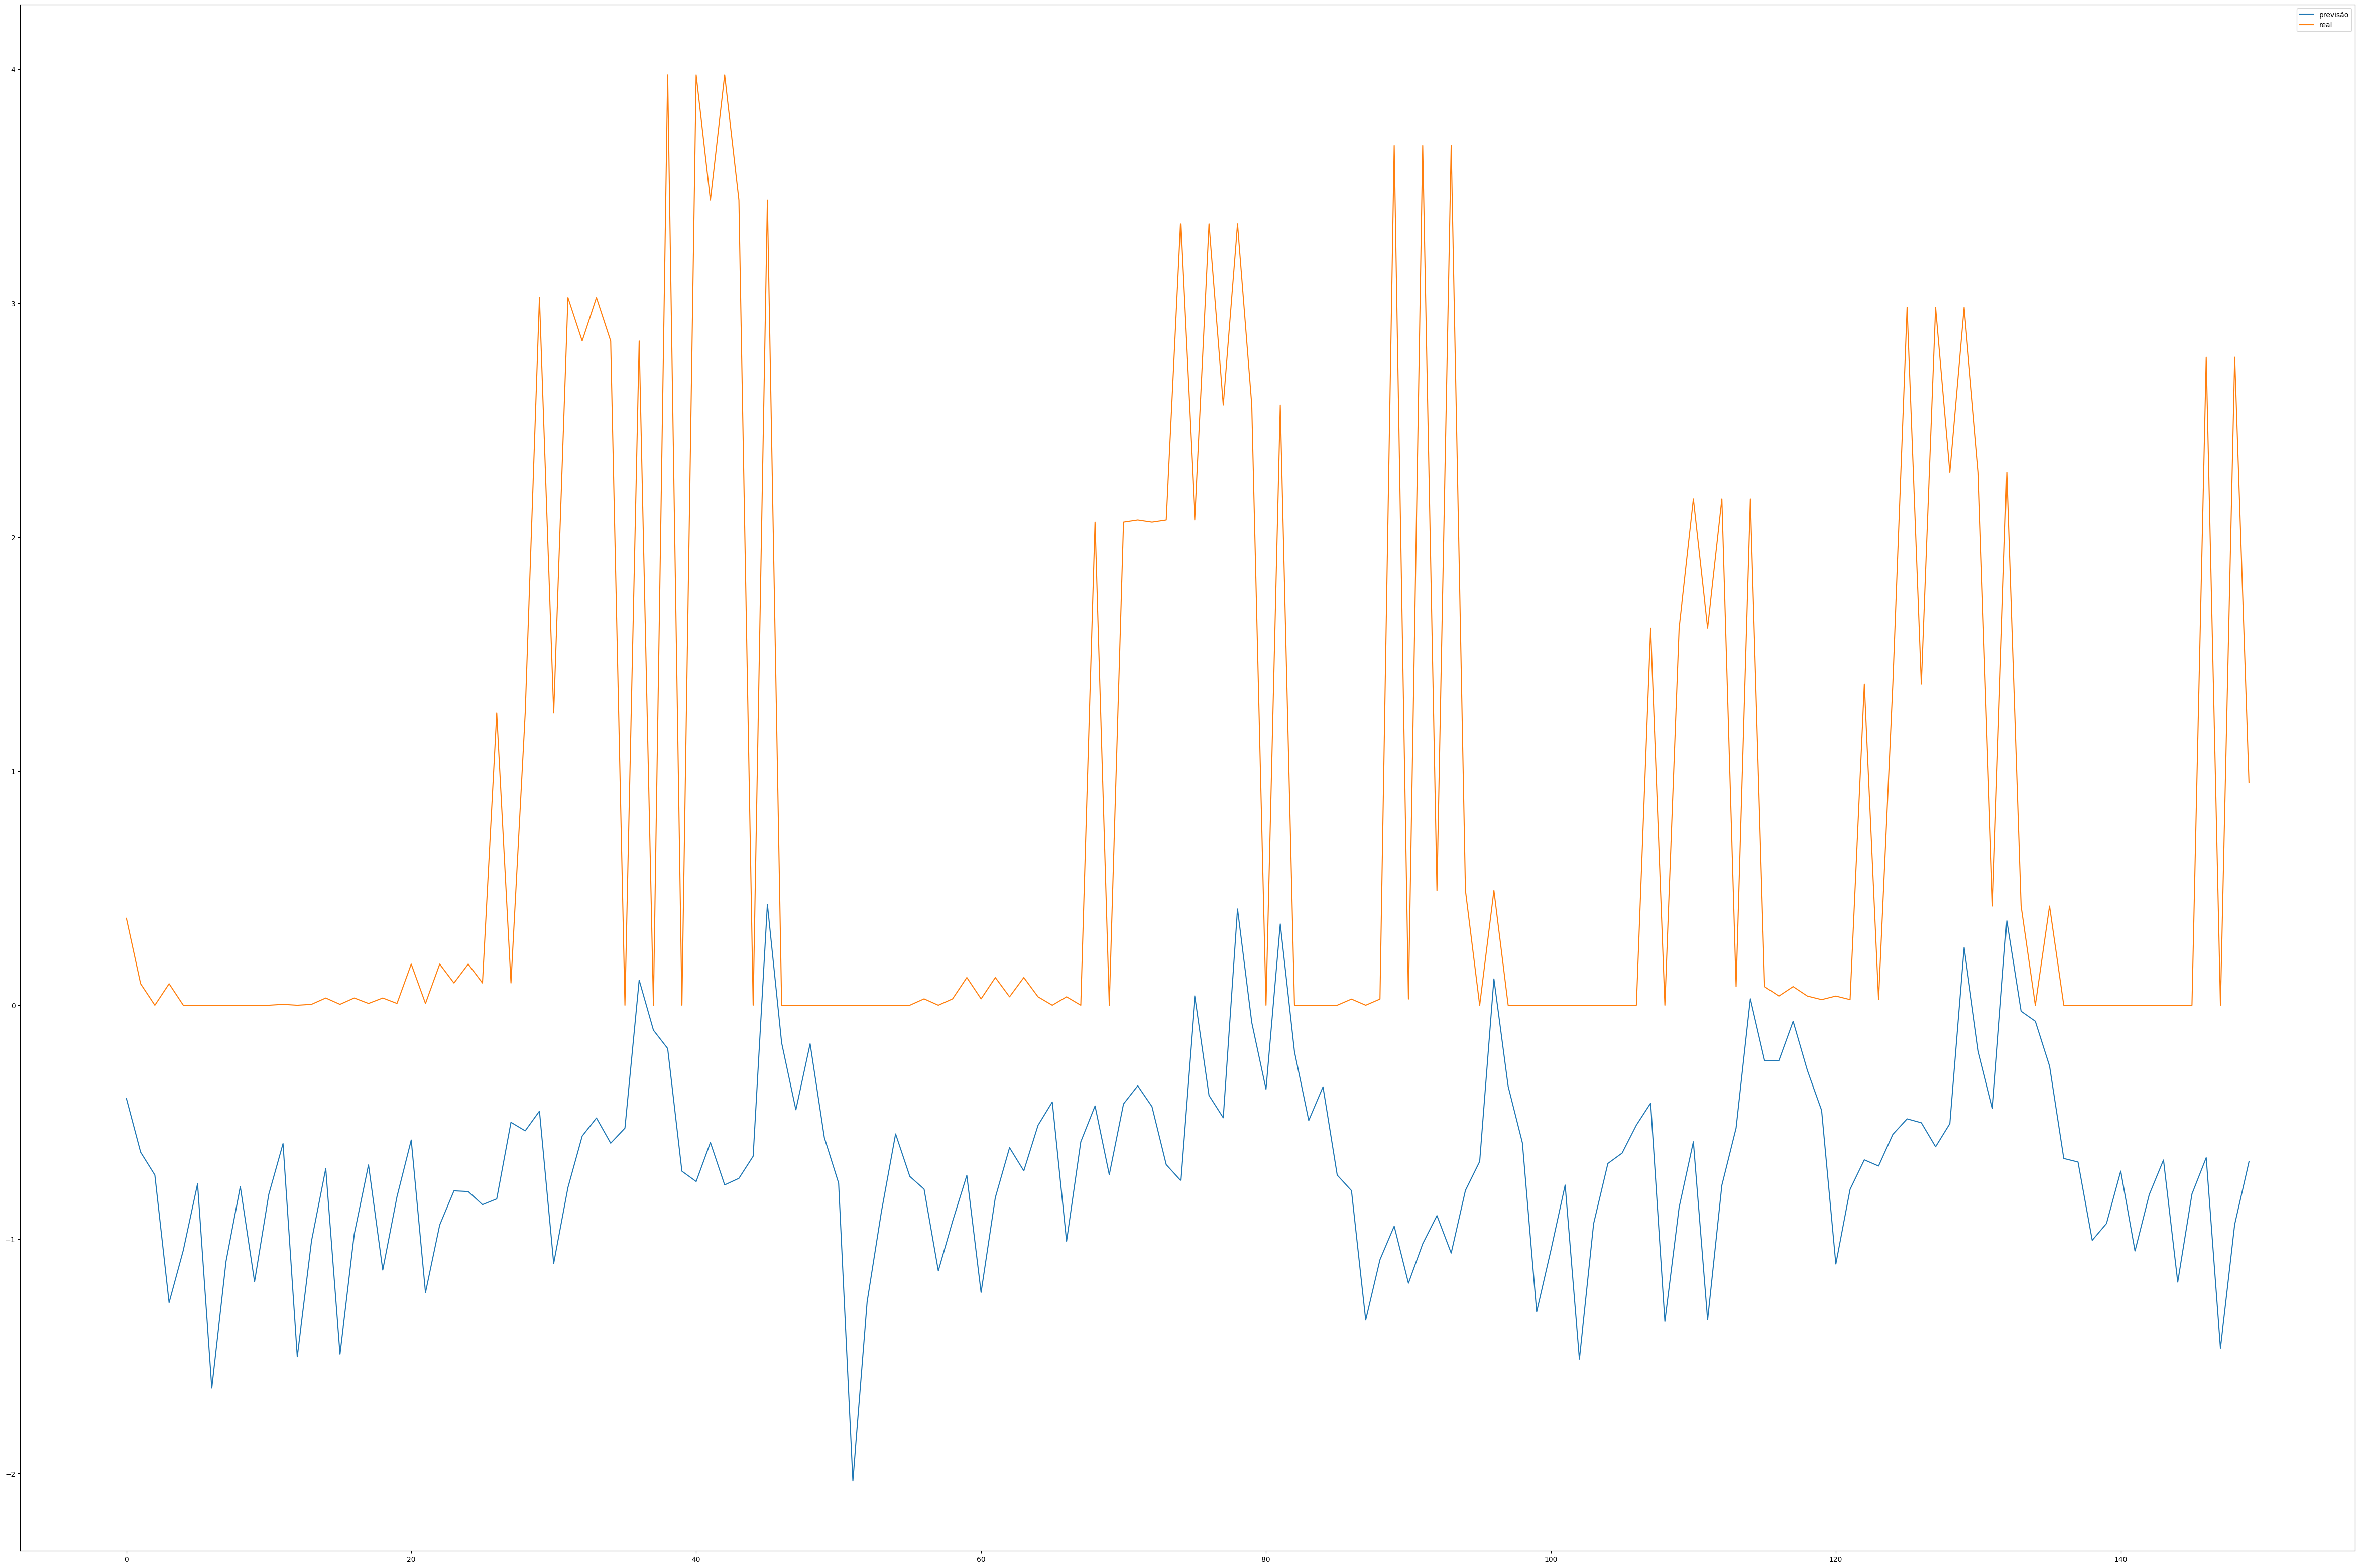

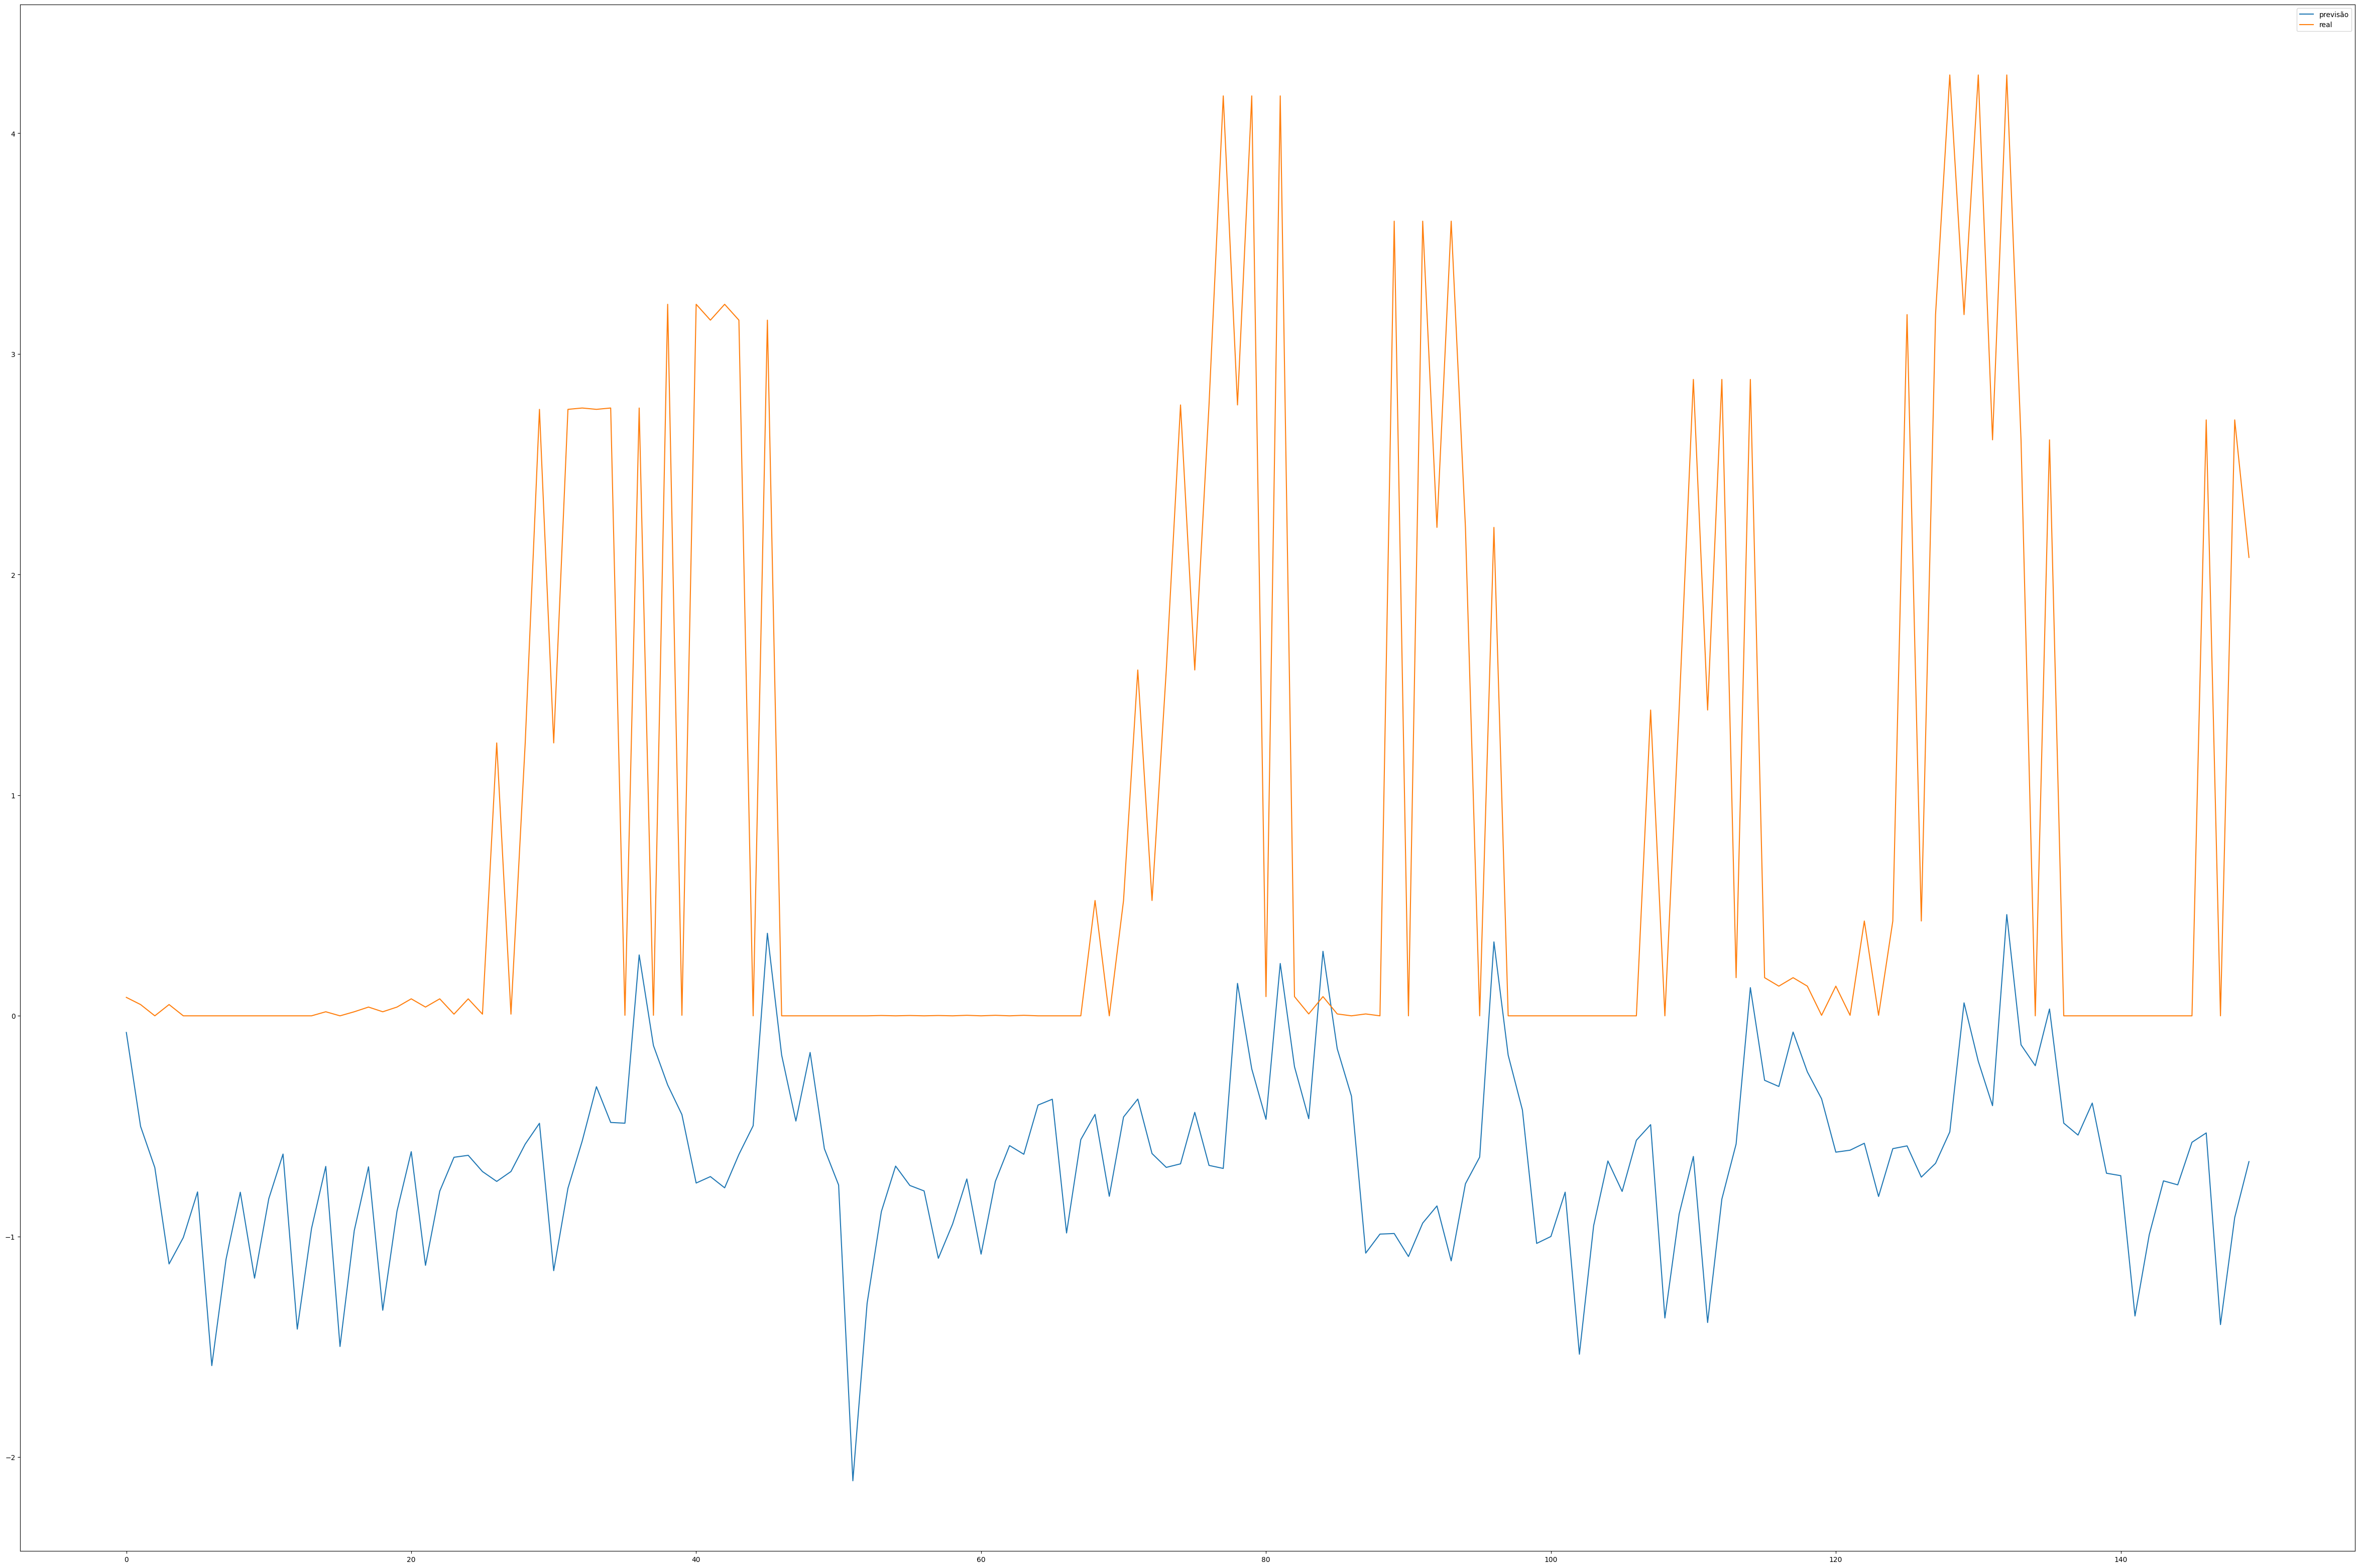

In [82]:
import matplotlib.pyplot as plt
T_max = 50
vertex_idx=2

print(pred.shape, y_test.shape)

plt.figure(figsize=(60,40))
plt.plot(pred[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
plt.plot(y_test[:T_max,:,vertex_idx].reshape(-1,1), label='real')
plt.legend()

import matplotlib.pyplot as plt
T_max = 50
vertex_idx=6

print(pred.shape, y_test.shape)

plt.figure(figsize=(60,40))
plt.plot(pred[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
plt.plot(y_test[:T_max,:,vertex_idx].reshape(-1,1), label='real')
plt.legend()

In [132]:
def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[..., station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[..., station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _flatten_unique_days(y, stride=1):
    """
    Remove dias sobrepostos entre batches.
    Espera y com shape [batches, horizon, stations] (ou [batches, horizon]).
    Retorna serie unica no tempo, sem repeticao de dias.
    """
    if hasattr(y, "detach"):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    if y.ndim == 2:
        y = y[:, :, None]  # [batches, horizon, 1]
        squeeze_back = True
    else:
        squeeze_back = False

    if y.ndim != 3:
        raise ValueError(f"y deve ter 2 ou 3 dimensoes. Recebido shape={y.shape}")

    batches, horizon, n_stations = y.shape
    if batches == 0:
        raise ValueError("y esta vazio.")
    if stride < 1:
        raise ValueError("stride deve ser >= 1.")

    if stride >= horizon:
        flat = y.reshape(batches * horizon, n_stations)
    else:
        parts = [y[0]]
        if batches > 1:
            tail = y[1:, -stride:, :].reshape(-1, n_stations)
            parts.append(tail)
        flat = np.concatenate(parts, axis=0)

    if squeeze_back:
        return flat[:, 0]
    return flat


def plot_precip_pred_vs_true(
    y_pred,
    y_true,
    station_idx=0,
    stride=1,
    start_date=None,
    station_name=None,
    ax=None,
    show=True,
    title=None,
):
    """
    Plota precipitacao predita vs real sem repetir dias.

    Parametros
    ----------
    y_pred, y_true : [batches, horizon, stations] (ou [batches, horizon])
        Exemplo: y_pred com shape [batchs, 5, 62].
    station_idx : int ou None
        Indice da estacao. Se None, plota a media das estacoes.
    stride : int
        Deslocamento entre batches. Para janelas deslizantes diarias, use 1.
    start_date : str ou None
        Data inicial (YYYY-MM-DD) para eixo x. Se None, usa indice.
    """
    y_pred_flat = _flatten_unique_days(y_pred, stride=stride)
    y_true_flat = _flatten_unique_days(y_true, stride=stride)

    if y_pred_flat.shape[0] != y_true_flat.shape[0]:
        raise ValueError(
            f"Tamanho temporal diferente: pred={y_pred_flat.shape[0]} vs true={y_true_flat.shape[0]}"
        )

    if y_pred_flat.ndim == 1:
        pred_series = y_pred_flat
        true_series = y_true_flat
        label = "serie"
    else:
        if station_idx is None:
            pred_series = y_pred_flat.mean(axis=1)
            true_series = y_true_flat.mean(axis=1)
            label = "media_estacoes"
        else:
            pred_series = y_pred_flat[:, station_idx]
            true_series = y_true_flat[:, station_idx]
            label = f"estacao {station_idx}" if station_name is None else station_name

    if start_date is not None:
        x = pd.date_range(start=start_date, periods=len(true_series), freq="D")
        xlabel = "Data"
    else:
        x = np.arange(len(true_series))
        xlabel = "Dia"

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    else:
        fig = ax.figure

    ax.plot(x, true_series, label="real", linewidth=2)
    ax.plot(x, pred_series, label="predito", linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Precipitacao")
    ax.set_title(title or f"Precipitacao real vs predita - {label}")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    n_in = model.cell.W_i.in_features
    seq_len = train_period - 1

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.sack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real


In [125]:
def eval_with_loader(model, loader, criterion, use_amp, amp_device, amp_dtype):
    model.eval()
    total_loss, total_mse, total_mae, total_mape, total_r2 = 0.0, 0.0, 0.0, 0.0, 0.0
    steps = 0
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()
    loss_fn = criterion if criterion is not None else nn.MSELoss()
    
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"eval_xb_batch{batch_idx}", xb)
            assert_finite(f"eval_yb_batch{batch_idx}", yb)

            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"eval_pred_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite eval loss on batch={batch_idx}")

            total_loss += loss.item()
            total_mse += mse_fn(pred, yb).item()
            total_mae += mae_fn(pred, yb).item()
            total_mape += safe_mape(yb, pred, eps=1e-3).item()
            total_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

    return {
        "loss": total_loss / max(steps, 1),
        "mse": total_mse / max(steps, 1),
        "mae": total_mae / max(steps, 1),
        "mape": total_mape / max(steps, 1),
        "r2": total_r2 / max(steps, 1),
    }


def train_batched_only(model, train_loader, val_loader, train_period, hidden_dim, epochs, lr, weight_decay, patience, criterion=None, run_dir=None):
    model = copy.deepcopy(model).to(device)
    print(criterion)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()
    loss_fn = criterion if criterion is not None else nn.MSELoss()

    # Estável para debug: AMP desligado
    use_amp = False
    amp_device = "cuda"
    amp_dtype = torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    print(f"train_batched_only: use_amp={use_amp}")

    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [], "train_mse": [], "train_mae": [], "train_mape": [], "train_r2": [],
        "val_loss": [], "val_mse": [], "val_mae": [], "val_mape": [], "val_r2": [], "epoch_time": []
    }

    for ep in range(epochs):
        t0 = time.perf_counter()
        model.train()
        train_loss = 0.0
        train_mse = 0.0
        train_mae = 0.0
        train_mape = 0.0
        train_r2 = 0.0
        steps = 0

        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"train_xb_epoch{ep}_batch{batch_idx}", xb)
            assert_finite(f"train_yb_epoch{ep}_batch{batch_idx}", yb)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"train_pred_epoch{ep}_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite loss epoch={ep} batch={batch_idx}")

            scaler.scale(loss).backward()
            
            

            for name, param in model.named_parameters():
                #if param.grad is not None:
                    #print(name, param.grad.abs().mean())
                if param.grad is not None and (not torch.isfinite(param.grad).all()):
                    raise RuntimeError(f"non-finite gradient in {name} epoch={ep} batch={batch_idx}")

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.8)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_mse += mse_fn(pred, yb).item()
            train_mae += mae_fn(pred, yb).item()
            train_mape += safe_mape(yb, pred, eps=1e-3).item()
            train_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

        history["train_loss"].append(train_loss / max(steps, 1))
        history["train_mse"].append(train_mse / max(steps, 1))
        history["train_mae"].append(train_mae / max(steps, 1))
        history["train_mape"].append(train_mape / max(steps, 1))
        history["train_r2"].append(train_r2 / max(steps, 1))

        val_metrics = eval_with_loader(model, val_loader, criterion=criterion, use_amp=use_amp, amp_device=amp_device, amp_dtype=amp_dtype)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_mape"].append(val_metrics["mape"])
        history["val_r2"].append(val_metrics["r2"])

        history["epoch_time"].append(time.perf_counter() - t0)

        print(
            f"epoch={ep+1}/{epochs}" 
            f"train_loss={history['train_loss'][-1]:e}/"
            f"val_loss={history['val_loss'][-1]:e}/"
            f"train_mae={history['train_mae'][-1]:e}/"
            f"val_mae={history['val_mae'][-1]:e}/" 
            f"val_mape={history['val_mape'][-1]:e}/"
            f"val_r2={history['val_r2'][-1]:e}"
        )

        if history["val_loss"][-1] < best_val_loss:
            best_val_loss = history["val_loss"][-1]
            counter = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            counter += 1

        if counter > patience:
            model.load_state_dict(best_model)
            print("Early Stopping")
            break

    model.load_state_dict(best_model)

    summary = {
        "hiddem_dim"        : hidden_dim,
        'train_period'      : train_period,
        "device"            : device,
        "epochs_requested"  : epochs,
        "epochs_ran"        : len(history["epoch_time"]),
        "lr"                : lr,
        "weight_decay"      : weight_decay,
        "patience"          : patience,
        "batch_size"        : train_loader.batch_size,
        "best_val_loss"     : best_val_loss,
        "last_val_mse"      : history["val_mse"][-1] if history["val_mse"] else None,
        "last_val_mae"      : history["val_mae"][-1] if history["val_mae"] else None,
        "last_val_mape"     : history["val_mape"][-1] if history["val_mape"] else None,
        "last_val_r2"       : history["val_r2"][-1] if history["val_r2"] else None,
        "total_time_s"      : float(sum(history["epoch_time"])),
    }

    if run_dir is not None:
        run_dir = Path(run_dir)
        run_dir.mkdir(parents=True, exist_ok=True)

        save_error_plots(
            str(run_dir),
            history["train_mse"], history["val_mse"],
            history["train_mae"], history["val_mae"],
            history["train_r2"],  history["val_r2"],
        )

        torch.save(history, run_dir / "hist.pt")
        torch.save(model.state_dict(), run_dir / "model_state_dict.pt")
        with open(run_dir / "run_summary.json", "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

    return model, history, summary


def weighted_mse_loss(
    y_pred,
    y_true,
    extreme_quantile=0.9,
    extreme_weight=10.0,
    is_log=True,
    eps=1e-6
):
    """
    Weighted MSE loss that emphasizes extreme rainfall, compatible with both
    log-transformed and raw targets.

    Args:
        y_pred: torch.Tensor, model predictions
        y_true: torch.Tensor, true values
        extreme_quantile: float, quantile to define "extreme rainfall" (default 0.9)
        extreme_weight: float, weight multiplier for extreme rainfall (default 5.0)
        is_log: bool, whether y_true (and y_pred) are log-transformed (default True)
        eps: small number to prevent log(0)
    """
    # Compute threshold in original scale
    if is_log:
        y_true_orig = torch.expm1(y_true)
        y_pred_orig = torch.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    threshold = torch.quantile(y_true_orig, extreme_quantile)

    # Create weights: extreme rainfall gets high weight
    weights = torch.ones_like(y_true)
    weights[y_true_orig > threshold] = extreme_weight

    # Weighted MSE (compute on original scale if is_log)
    if is_log:
        # compute loss in log space (optional: can use pred vs true in log)
        loss = torch.mean(weights * (y_pred - y_true) ** 2)
    else:
        loss = torch.mean(weights * (y_pred - y_true) ** 2)

    return loss

# Pipeline Test


In [265]:
X = torch.cat([X_tp, X_year, X_temp, X_vv, X_sh], dim=-1)

print(X.shape)
X = X[-35:] 
print(X.shape)

torch.Size([9497, 62, 26])
torch.Size([35, 62, 26])


In [266]:
#CRIAÇÃO DE JANELAS DE TEMPO

Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)

X_train, y_train, X_val, y_val, X_test, y_test_raw = train_split(Xs, ys)


target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test_raw, target_mean, target_std)

"""
X_train[...,0] = torch.log1p(X_train[...,0])
X_val[...,0] = torch.log1p(X_val[...,0])
X_test[...,0] = torch.log1p(X_test[...,0])

y_train = torch.log1p(y_train)
y_val = torch.log1p(y_val)
y_test = torch.log1p(y_test_raw)
"""

# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)


"""
normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)
"""
# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

train batches: 1 val batches: 1 test batches: 1


In [271]:
for lr in [1e-3]:
    for hidden_dim in [512]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout).to(device)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "pipeline_test")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=3000, lr=lr, weight_decay=1e-4, patience=3000, criterion=weighted_mse_loss,run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )

========================HIDDEN_DIM: 512=============================
<function weighted_mse_loss at 0x0000014941DA5580>
train_batched_only: use_amp=False
epoch=1/3000train_loss=8.170359e+00/val_loss=7.135911e+00/train_mae=1.037566e+00/val_mae=9.281574e-01/val_mape=1.663349e+02/val_r2=-4.245504e-01
epoch=2/3000train_loss=4.128218e+00/val_loss=6.041253e+00/train_mae=7.360864e-01/val_mae=8.828552e-01/val_mape=1.777546e+02/val_r2=-2.613227e-01
epoch=3/3000train_loss=1.984561e+00/val_loss=5.692829e+00/train_mae=6.141501e-01/val_mae=8.715630e-01/val_mape=1.916336e+02/val_r2=-2.299649e-01
epoch=4/3000train_loss=1.276725e+00/val_loss=5.334016e+00/train_mae=6.081967e-01/val_mae=8.422331e-01/val_mape=1.909993e+02/val_r2=-1.417061e-01
epoch=5/3000train_loss=1.011695e+00/val_loss=5.336225e+00/train_mae=6.470248e-01/val_mae=8.499182e-01/val_mape=1.905846e+02/val_r2=-1.486037e-01
epoch=6/3000train_loss=9.762512e-01/val_loss=5.172520e+00/train_mae=6.415925e-01/val_mae=8.565231e-01/val_mape=1.925708e+

In [273]:
for lr in [5e-4]:
    for hidden_dim in [512]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout).to(device)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "pipeline_test")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=3000, lr=lr, weight_decay=1e-3, patience=3000, criterion=weighted_mse_loss,run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )

========================HIDDEN_DIM: 512=============================
<function weighted_mse_loss at 0x0000014941DA5580>
train_batched_only: use_amp=False
epoch=1/3000train_loss=6.978472e+00/val_loss=7.399652e+00/train_mae=9.158318e-01/val_mae=1.036544e+00/val_mape=1.561220e+02/val_r2=-6.561419e-01
epoch=2/3000train_loss=4.262582e+00/val_loss=7.041304e+00/train_mae=7.514604e-01/val_mae=1.019289e+00/val_mape=1.567451e+02/val_r2=-6.014923e-01
epoch=3/3000train_loss=2.690191e+00/val_loss=6.799212e+00/train_mae=6.331453e-01/val_mae=1.029885e+00/val_mape=1.724073e+02/val_r2=-6.212612e-01
epoch=4/3000train_loss=1.869444e+00/val_loss=6.907419e+00/train_mae=5.960060e-01/val_mae=1.034046e+00/val_mape=1.624893e+02/val_r2=-6.493807e-01
epoch=5/3000train_loss=1.435458e+00/val_loss=6.789660e+00/train_mae=5.704768e-01/val_mae=1.019869e+00/val_mape=1.631529e+02/val_r2=-6.255018e-01
epoch=6/3000train_loss=1.123809e+00/val_loss=6.458961e+00/train_mae=5.666072e-01/val_mae=1.010935e+00/val_mape=1.620468e+